# ABSA Aspect-Sentiment Analysis: NYC Tripadvisor Reviews (5000 Sample)

This notebook provides a comprehensive analysis of aspect-based sentiment (ABSA) results for NYC Tripadvisor reviews, including descriptive statistics, VADER sanity checks, and deep dives into the most frequent aspects.

## 1. Detect Repository Root and Set Data Path

Automatically detect the project root and construct the path to the silver staged folder for data loading.

In [1]:
# Detect project root and set data path
from pathlib import Path

def find_project_root():
    current = Path.cwd()
    for _ in range(12):
        if (current / ".projectroot").exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError("Could not find project root (.projectroot marker not found).")

project_root = find_project_root()
silver_staged = project_root / "data" / "silver" / "tripadvisor" / "staged_primary"
dataset_path = silver_staged / "tripadvisor_nyc_absa_llm_full_5000_staged.parquet"
print(f"Project root: {project_root}")
print(f"Dataset path: {dataset_path}")

Project root: /Users/kristinakogan/code/TinaKgn/tourism_data_project
Dataset path: /Users/kristinakogan/code/TinaKgn/tourism_data_project/data/silver/tripadvisor/staged_primary/tripadvisor_nyc_absa_llm_full_5000_staged.parquet


## 2. Load Dataset from Silver Staged Folder

Load the NYC Tripadvisor ABSA 5000-sample dataset using pandas.

In [2]:
import pandas as pd

df = pd.read_parquet(dataset_path)
print(f"Loaded {len(df):,} rows.")
df.head()

Loaded 5,000 rows.


,orig_index,rvw_id_pr,usr_id_pr,lst_id_pr,rvw_text_pr,rvw_text_flags_pr,rvw_vader_pr,rvw_year_pr,rvw_month_pr,lst_lat_pr,lst_lon_pr,lst_metro_code_pr,is_accommodation_pr,is_restaurant_pr,is_nightlife_pr,is_entertainment_pr,is_tours_pr,is_events_pr,llm_aspects
0,67961,4187855025034601237,125711495911142695,7216442717905379776,"Because of problems with BA at Heathrow, we di...",emoji:0|punct:0|space:0|long:1,0.9962,2015,1,40.769001,-73.982948,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."
1,62951,16030209335468258604,7148981648026715854,12900033009701489607,I have been here several times and have found ...,emoji:0|punct:0|space:0|long:0,0.9789,2015,1,40.764702,-73.968956,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."
2,52698,8756536453710533938,12773076195504996377,2708177658169265045,This next comment is not only a reflection of ...,emoji:0|punct:2|space:0|long:0,0.9706,2015,1,40.752201,-73.981155,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."
3,36461,4714873220144592321,8120103518546386781,10697613456557793400,Nice hotel thats central in location to many h...,emoji:0|punct:0|space:0|long:0,0.9832,2015,1,40.720901,-74.005623,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."
4,69689,14787115221043274069,14320649791029870421,12307477088580125724,Found ourselves stranded in NYC because of sno...,emoji:0|punct:2|space:0|long:0,0.9829,2015,1,40.751301,-73.984573,35620,1,0,0,0,0,0,"{""accommodation quality"": {""present"": true, ""s..."


## 3. Descriptive Statistics of Dataset

Compute and display descriptive statistics for aspects, sentiments, and review lengths.

Aspect count:


aspect
accommodation quality    4994
value for money          4867
staff friendliness       4801
service quality          4294
location                 4264
room size                4008
atmosphere               3437
cleanliness              3399
food quality             1531
noise level              1338
drink quality            1132
tours                     855
wait time                 440
crowding                  324
availability              257
Name: count, dtype: int64


Sentiment distribution:


sentiment
Positive    28633
Neutral      7020
Negative     2562
None         1726
Name: count, dtype: int64

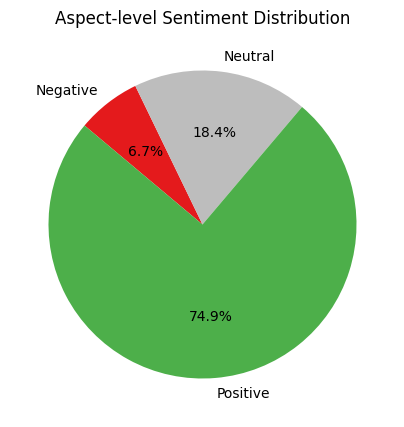

In [10]:
# Descriptive statistics for aspects, sentiments, and review lengths
from collections import Counter
import matplotlib.pyplot as plt

# Flatten aspect-sentiment pairs
aspect_sentiment_records = []
for _, row in df.iterrows():
    aspects = row.get('llm_aspects') or row.get('absa_aspects')
    if isinstance(aspects, str):
        import json
        try:
            aspects = json.loads(aspects)
        except Exception:
            continue
    if not isinstance(aspects, dict):
        continue
    for aspect, payload in aspects.items():
        sentiment = str(payload.get('sentiment', '')).strip().capitalize()
        aspect_sentiment_records.append({
            'aspect': aspect,
            'sentiment': sentiment,
            'review_text': row['rvw_text_pr'] if 'rvw_text_pr' in row else row.get('text', '')
        })

aspect_sentiment_df = pd.DataFrame(aspect_sentiment_records)

print("Aspect count:")
display(aspect_sentiment_df['aspect'].value_counts().head(20))
print("\nSentiment distribution:")
display(aspect_sentiment_df['sentiment'].value_counts())

# Pie chart for sentiment distribution (drop None/empty, use heatmap colors)
sentiment_order = ['Negative', 'Neutral', 'Positive']
color_map = {'Positive': '#4daf4a', 'Neutral': '#bdbdbd', 'Negative': '#e41a1c'}
sentiment_counts = aspect_sentiment_df['sentiment'].value_counts()
sentiment_counts = sentiment_counts[[s for s in sentiment_order if s in sentiment_counts.index]]
plt.figure(figsize=(5,5))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=[color_map[s] for s in sentiment_counts.index], startangle=140, counterclock=False)
plt.title('Aspect-level Sentiment Distribution')
plt.show()

## 4. Sanity Check: Compare ABSA Sentiment Scores with VADER Scores

Compare ABSA sentiment with VADER sentiment using scatter plots and correlation metrics.

VADER vs ABSA SENTIMENT COMPARISON

📊 COVERAGE STATISTICS
--------------------------------------------------------------------------------
Total reviews in sample: 5000
Reviews with ≥1 aspect detected: 5000 (100.0%)
Total aspect detections: 39941
Average aspects per review (among those with aspects): 7.99

🎯 ASPECTS DETECTED (top 10)
--------------------------------------------------------------------------------
  accommodation quality......... 4994 detections
  value for money............... 4867 detections
  staff friendliness............ 4801 detections
  service quality............... 4294 detections
  location...................... 4264 detections
  room size..................... 4008 detections
  atmosphere.................... 3437 detections
  cleanliness................... 3399 detections
  food quality.................. 1531 detections
  noise level................... 1338 detections

📈 VADER SENTIMENT DISTRIBUTION (review level)
----------------------------------------------

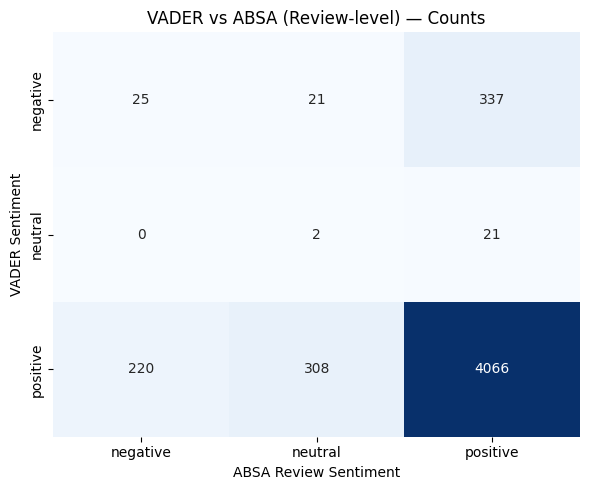

Row percentages (where VADER predicts X, ABSA predicts Y):


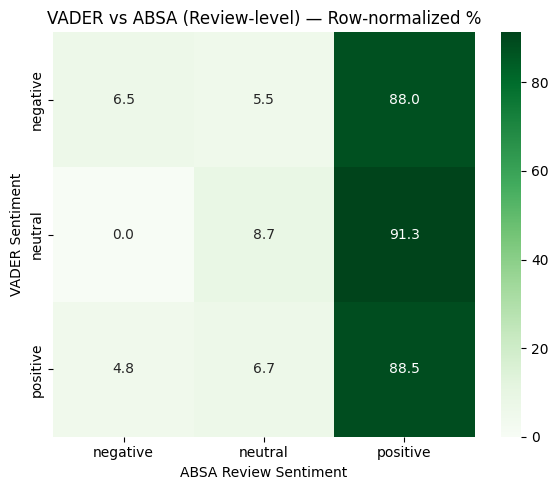

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === VADER vs ABSA Comparison Analysis ===
print("=" * 80)
print("VADER vs ABSA SENTIMENT COMPARISON")
print("=" * 80)

# Use the already loaded df and the column 'rvw_vader_pr'
# Extract VADER sentiment (classify into pos/neg/neutral based on compound score)
def vader_sentiment(score):
    if pd.isna(score):
        return 'unknown'
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_sentiment'] = df['rvw_vader_pr'].apply(vader_sentiment)

aspect_records = []

# Helper to decide whether an aspect entry indicates a real detection
def _is_aspect_detected(details):
    if isinstance(details, dict):
        if 'present' in details:
            return bool(details.get('present'))
        sentiment = details.get('sentiment')
        confidence = details.get('confidence')
        if sentiment and str(sentiment).lower() not in ('unknown', 'none'):
            return True
        if confidence is not None and not (isinstance(confidence, float) and np.isnan(confidence)):
            return True
        return False
    return False

for idx, row in df.iterrows():
    absa_aspects = row.get('llm_aspects') or row.get('absa_aspects')
    vader_sent = row.get('vader_sentiment')

    # Parse aspects if string
    if isinstance(absa_aspects, str):
        import json
        try:
            absa_aspects = json.loads(absa_aspects)
        except Exception:
            continue

    if isinstance(absa_aspects, dict):
        for aspect, details in absa_aspects.items():
            if _is_aspect_detected(details):
                if not isinstance(details, dict):
                    details = {}

                aspect_records.append({
                    'orig_index': idx,
                    'aspect': aspect,
                    'absa_sentiment': details.get('sentiment', 'unknown'),
                    'vader_sentiment': vader_sent,
                    'confidence': details.get('confidence', np.nan)
                })

aspect_comparison_df = pd.DataFrame(aspect_records)

# Compute detected-aspect count per review
def _count_detected(aspects):
    if isinstance(aspects, str):
        import json
        try:
            aspects = json.loads(aspects)
        except Exception:
            return 0
    if not isinstance(aspects, dict):
        return 0
    return sum(1 for v in aspects.values() if _is_aspect_detected(v))

# Coverage and basic stats
total_reviews = len(df)
detected_counts = df['llm_aspects'].apply(_count_detected) if 'llm_aspects' in df.columns else df['absa_aspects'].apply(_count_detected)
reviews_with_aspects = int(detected_counts.gt(0).sum())
total_aspect_detections = len(aspect_records)
avg_aspects_per_detected_review = total_aspect_detections / max(1, reviews_with_aspects)

print(f"\n📊 COVERAGE STATISTICS")
print("-" * 80)
print(f"Total reviews in sample: {total_reviews}")
print(f"Reviews with ≥1 aspect detected: {reviews_with_aspects} ({100 * reviews_with_aspects / max(1, total_reviews):.1f}%)")
print(f"Total aspect detections: {total_aspect_detections}")
print(f"Average aspects per review (among those with aspects): {avg_aspects_per_detected_review:.2f}")

# Top detected aspects
print(f"\n🎯 ASPECTS DETECTED (top 10)")
print("-" * 80)
if total_aspect_detections > 0:
    top_aspects = aspect_comparison_df['aspect'].value_counts().head(10)
    for aspect, count in top_aspects.items():
        print(f"  {aspect:.<30} {count:>4} detections")
else:
    print("  (no detected aspects found)")

# Distributions
print(f"\n📈 VADER SENTIMENT DISTRIBUTION (review level)")
print("-" * 80)
vader_dist = df['vader_sentiment'].value_counts().sort_index()
for sent, count in vader_dist.items():
    pct = 100 * count / total_reviews
    print(f"  {sent:.<20} {count:>4} ({pct:>5.1f}%)")

print(f"\n📈 ABSA SENTIMENT DISTRIBUTION (aspect-level)")
print("-" * 80)
if total_aspect_detections > 0:
    absa_dist = aspect_comparison_df['absa_sentiment'].value_counts().sort_index()
    for sent, count in absa_dist.items():
        pct = 100 * count / total_aspect_detections
        print(f"  {sent:.<20} {count:>4} ({pct:>5.1f}%)")
else:
    print("  (no aspect-level sentiments to show)")

# === NEW: Aspect-level: ABSA vs ABSA confidence ===
print(f"\n🔍 ASPECT-LEVEL: ABSA SENTIMENT vs CONFIDENCE")
print("-" * 80)
print("This shows the distribution of ABSA model confidence by sentiment label.")
print("(Higher confidence = model is more certain about that aspect's sentiment)")
print()
if total_aspect_detections > 0:
    # Remove None/NaN from unique sentiments for sorting
    unique_sentiments = [s for s in aspect_comparison_df['absa_sentiment'].unique() if isinstance(s, str) and s.strip() != '']
    unique_sentiments = sorted(unique_sentiments)
    for sent in unique_sentiments:
        sent_data = aspect_comparison_df[aspect_comparison_df['absa_sentiment'] == sent]['confidence']
        if len(sent_data) > 0:
            mean_conf = sent_data.mean()
            min_conf = sent_data.min()
            max_conf = sent_data.max()
            count = len(sent_data)
            print(f"  {sent:.<15} | Count: {count:>4} | Mean conf: {mean_conf:.3f} | Min: {min_conf:.3f} | Max: {max_conf:.3f}")
else:
    print("  (no aspect-level sentiments to analyze)")

# === NEW: Review-level: VADER vs review-average ABSA ===
print(f"\n🔍 REVIEW-LEVEL: VADER vs REVIEW-AVERAGE ABSA SENTIMENT")
print("-" * 80)
print("For each review, we compute the most common ABSA sentiment (mode) across all detected aspects,")
print("then compare to the review-level VADER sentiment.")
print()

# Build review-level ABSA averages (using mode—most common aspect sentiment)
review_absa_sentiments = {}
for idx, row in df.iterrows():
    absa_aspects = row.get('llm_aspects') or row.get('absa_aspects')
    # Parse aspects if string
    if isinstance(absa_aspects, str):
        import json
        try:
            absa_aspects = json.loads(absa_aspects)
        except Exception:
            continue
    if isinstance(absa_aspects, dict):
        detected_sentiments = []
        for aspect, details in absa_aspects.items():
            if _is_aspect_detected(details):
                sent = details.get('sentiment', 'unknown') if isinstance(details, dict) else 'unknown'
                if sent and str(sent).lower() not in ('unknown', 'none'):
                    detected_sentiments.append(sent)
        # Compute mode (most common sentiment) for this review's aspects
        if detected_sentiments:
            from collections import Counter
            sentiment_counts = Counter(detected_sentiments)
            review_absa_sentiment = sentiment_counts.most_common(1)[0][0]
            review_absa_sentiments[idx] = review_absa_sentiment

# Now compare review-level VADER to review-average ABSA
review_comparison_records = []
for idx, row in df.iterrows():
    vader_sent = row.get('vader_sentiment')
    if idx in review_absa_sentiments:
        absa_review_sent = review_absa_sentiments[idx]
        review_comparison_records.append({
            'orig_index': idx,
            'vader_sentiment': vader_sent,
            'absa_review_sentiment': absa_review_sent,
            'match': vader_sent == absa_review_sent
        })

if review_comparison_records:
    review_comparison_df = pd.DataFrame(review_comparison_records)

    # Confusion matrix (VADER rows → ABSA columns)
    conf_matrix = pd.crosstab(review_comparison_df['vader_sentiment'],
                               review_comparison_df['absa_review_sentiment'],
                               margins=False)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )
    plt.title("VADER vs ABSA (Review-level) — Counts")
    plt.xlabel("ABSA Review Sentiment")
    plt.ylabel("VADER Sentiment")
    plt.tight_layout()
    plt.show()

    # Row-normalized percentages
    conf_pct = pd.crosstab(review_comparison_df['vader_sentiment'],
                            review_comparison_df['absa_review_sentiment'],
                            normalize='index').fillna(0)
    print("Row percentages (where VADER predicts X, ABSA predicts Y):")

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_pct * 100,
        annot=True,
        fmt=".1f",
        cmap="Greens",
        cbar=True
    )
    plt.title("VADER vs ABSA (Review-level) — Row-normalized %")
    plt.xlabel("ABSA Review Sentiment")
    plt.ylabel("VADER Sentiment")
    plt.tight_layout()
    plt.show()

## 5. Aspect Distribution Bar Chart

Visualize the frequency of each aspect in the dataset.

/var/folders/2l/8rtkcb8x1lq1l5hrrsf7kghw0000gn/T/ipykernel_44265/40110129.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette='Blues_r')


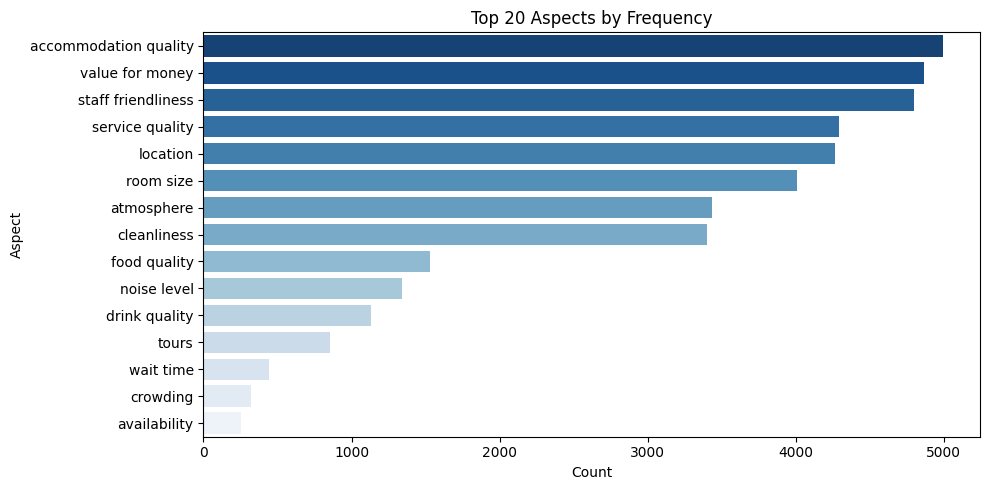

In [5]:
# Bar chart: aspect frequency
top_n = 20
plt.figure(figsize=(10,5))
aspect_counts = aspect_sentiment_df['aspect'].value_counts().head(top_n)
sns.barplot(x=aspect_counts.values, y=aspect_counts.index, palette='Blues_r')
plt.xlabel('Count')
plt.ylabel('Aspect')
plt.title(f'Top {top_n} Aspects by Frequency')
plt.tight_layout()
plt.show()

## 6. Sentiment per Aspect Bar Chart

Plot the distribution of sentiment (positive, neutral, negative) for each aspect.

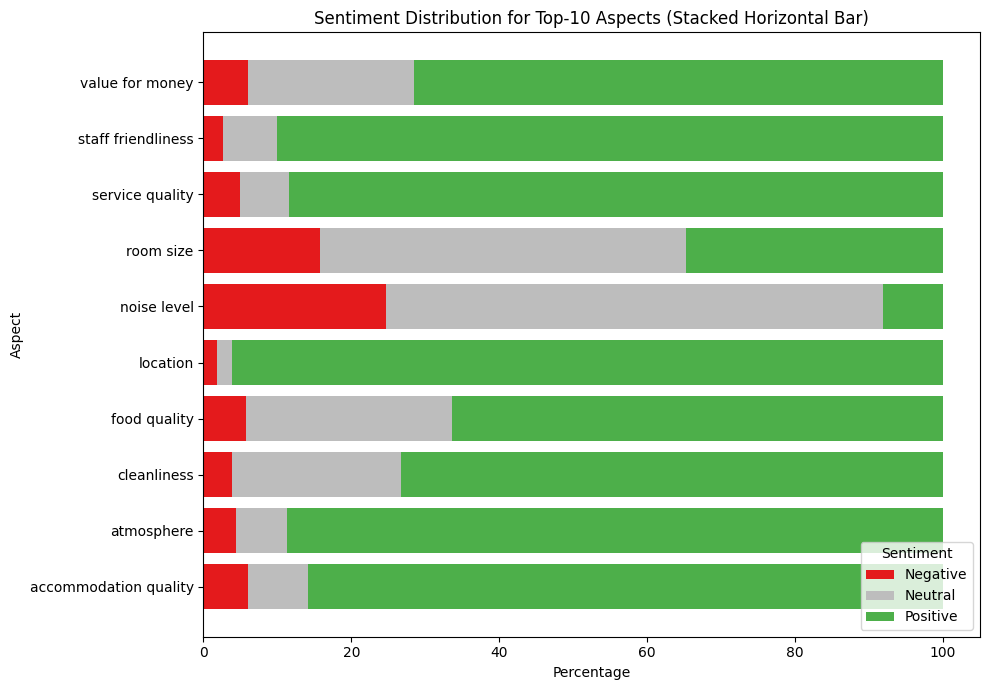

In [6]:
# Stacked horizontal bar chart: sentiment distribution per aspect (Negative, Neutral, Positive, with heatmap colors)
import matplotlib.pyplot as plt
import numpy as np

top_aspects = aspect_sentiment_df['aspect'].value_counts().head(10).index
sentiment_order = ['Negative', 'Neutral', 'Positive']
color_map = {'Positive': '#4daf4a', 'Neutral': '#bdbdbd', 'Negative': '#e41a1c'}

# Prepare data for stacked bar chart
bar_data = aspect_sentiment_df[aspect_sentiment_df['aspect'].isin(top_aspects)]\
    .groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)

# Ensure all sentiment columns exist and in correct order
for col in sentiment_order:
    if col not in bar_data.columns:
        bar_data[col] = 0
bar_data = bar_data[sentiment_order]

# Normalize to get percentages per aspect (row)
bar_pct = bar_data.div(bar_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 7))
left = np.zeros(len(bar_pct))
for sentiment in sentiment_order:
    values = bar_pct[sentiment].values
    ax.barh(bar_pct.index, values, left=left, label=sentiment, color=color_map[sentiment])
    left += values

ax.set_xlabel('Percentage')
ax.set_ylabel('Aspect')
ax.set_title('Sentiment Distribution for Top-10 Aspects (Stacked Horizontal Bar)')
ax.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
plt.show()

## 7. Sentiment per Aspect Heatmap

Generate a heatmap with aspects and sentiment, colored from green (positive) to red (negative).

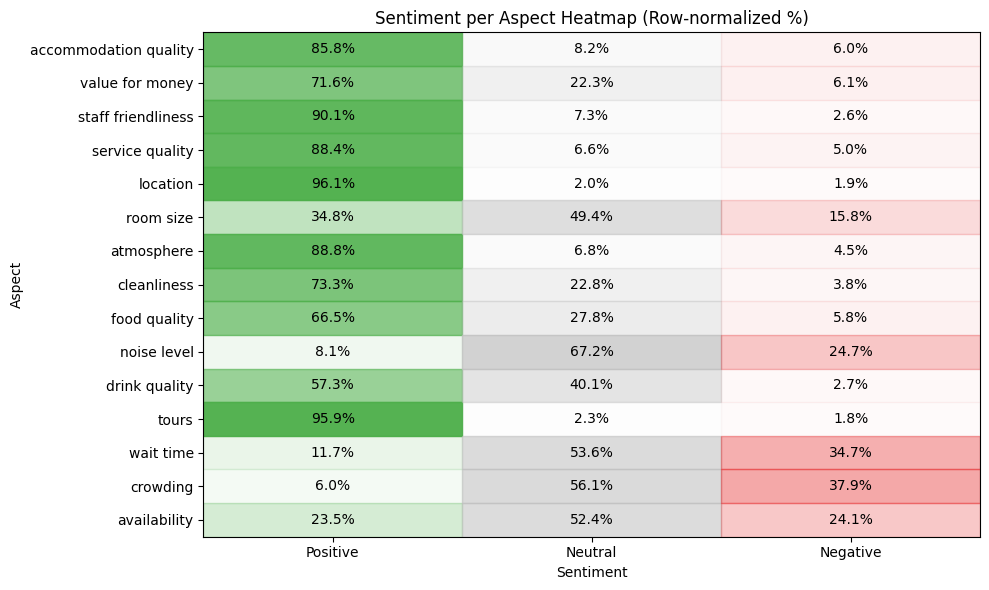

In [7]:
# Heatmap: sentiment per aspect (row-normalized, color by sentiment)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
heatmap_data = aspect_sentiment_df.groupby(['aspect', 'sentiment']).size().unstack(fill_value=0)
top_heatmap_aspects = aspect_sentiment_df['aspect'].value_counts().head(15).index
heatmap_data = heatmap_data.loc[top_heatmap_aspects]

# Ensure all sentiment columns exist
sentiment_order = ['Positive', 'Neutral', 'Negative']
for col in sentiment_order:
    if col not in heatmap_data.columns:
        heatmap_data[col] = 0
heatmap_data = heatmap_data[sentiment_order]

# Row-normalize to percentages
row_sums = heatmap_data.sum(axis=1).replace(0, np.nan)
heatmap_pct = heatmap_data.div(row_sums, axis=0).fillna(0) * 100

# Custom colormap: green (positive), grey (neutral), red (negative)
from matplotlib.colors import ListedColormap, BoundaryNorm

# Build a custom colormap for columns: green, grey, red
cmap = ListedColormap(['#4daf4a', '#bdbdbd', '#e41a1c'])

# Draw heatmap with color intensity per value, but fixed color per column
fig, ax = plt.subplots(figsize=(10,6))
for i, col in enumerate(sentiment_order):
    vals = heatmap_pct[col].values.reshape(-1, 1)
    # Normalize intensity for each column
    norm = plt.Normalize(0, 100)
    colors = np.array([cmap(i)] * len(vals))
    # Adjust alpha by value (intensity)
    for j, v in enumerate(vals):
        ax.add_patch(plt.Rectangle((i, j), 1, 1, color=cmap(i), alpha=norm(v[0])))

# Overlay text annotations
for i, aspect in enumerate(heatmap_pct.index):
    for j, col in enumerate(sentiment_order):
        val = heatmap_pct.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f"{val:.1f}%", va='center', ha='center', color='black', fontsize=10)

ax.set_xticks(np.arange(len(sentiment_order)) + 0.5)
ax.set_xticklabels(sentiment_order)
ax.set_yticks(np.arange(len(heatmap_pct.index)) + 0.5)
ax.set_yticklabels(heatmap_pct.index)
ax.set_xlim(0, len(sentiment_order))
ax.set_ylim(0, len(heatmap_pct.index))
ax.invert_yaxis()
ax.set_xlabel('Sentiment')
ax.set_ylabel('Aspect')
ax.set_title('Sentiment per Aspect Heatmap (Row-normalized %)')
plt.tight_layout()
plt.show()

## 8. Word Clouds for Top-5 Aspects

Generate word clouds for the review texts associated with each of the top-5 aspects.

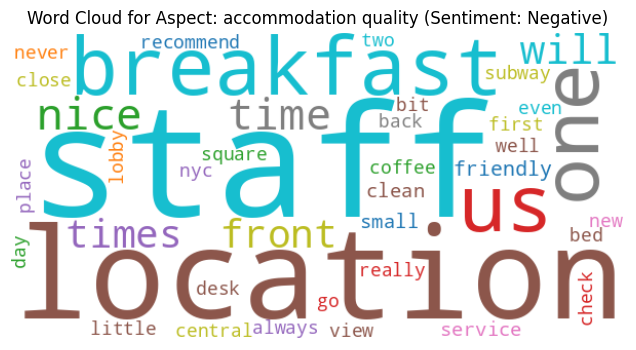

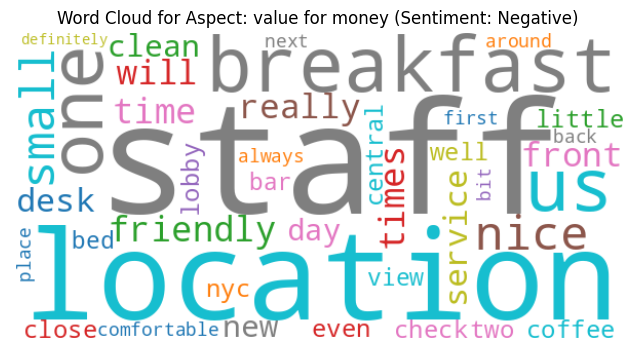

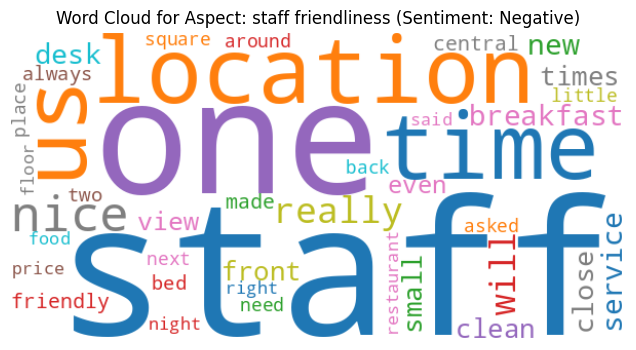

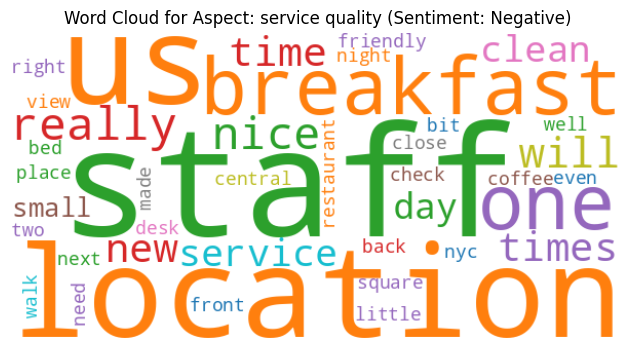

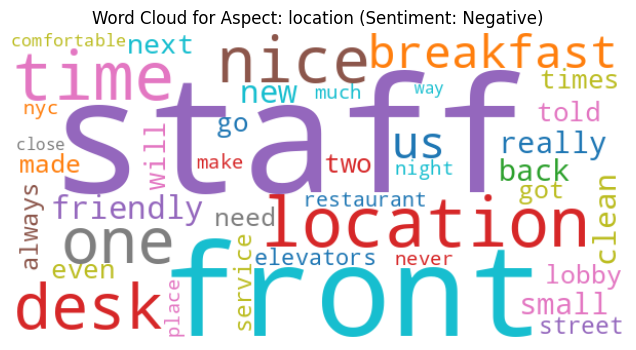

In [16]:
# Word clouds for top-5 aspects with stopwords, frequency threshold, max words limit, and sentiment filter
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# Words to exclude from word clouds (custom + standard stopwords)
custom_stopwords = set(["hotel", "room", "rooms", "stay", "stayed","great","good"])
all_stopwords = STOPWORDS.union(custom_stopwords)
word_freq_threshold = 5  # Minimum frequency for a word to appear in the word cloud
max_words = 40  # Maximum number of words to display in the word cloud

# Set this variable to 'Positive', 'Negative', or None to filter by sentiment
sentiment_filter = "Negative"  # e.g., 'Positive', 'Negative', or None for all

# Ensure top5_aspects is defined
top5_aspects = aspect_sentiment_df['aspect'].value_counts().head(5).index.tolist()

for aspect in top5_aspects:
    if sentiment_filter:
        filtered_df = aspect_sentiment_df[(aspect_sentiment_df['aspect'] == aspect) & (aspect_sentiment_df['sentiment'] == sentiment_filter)]
    else:
        filtered_df = aspect_sentiment_df[aspect_sentiment_df['aspect'] == aspect]
    texts = filtered_df['review_text'].dropna().astype(str)
    if texts.empty:
        print(f"No reviews for aspect: {aspect} with sentiment: {sentiment_filter if sentiment_filter else 'any'}")
        continue
    text_blob = ' '.join(texts)

    # Tokenize and count word frequencies, filtering stopwords (NLP best practice)
    words = [w.lower() for w in text_blob.split() if w.isalpha() and w.lower() not in all_stopwords]
    word_counts = Counter(words)
    # Filter by frequency threshold
    filtered_word_counts = {w: c for w, c in word_counts.items() if c >= word_freq_threshold}
    # Limit to max_words most common words
    filtered_word_counts = dict(Counter(filtered_word_counts).most_common(max_words))
    if not filtered_word_counts:
        print(f"No words above threshold for aspect: {aspect} (sentiment: {sentiment_filter if sentiment_filter else 'any'})")
        continue

    wc = WordCloud(width=600, height=300, background_color='white', colormap='tab10', stopwords=all_stopwords, max_words=max_words).generate_from_frequencies(filtered_word_counts)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Aspect: {aspect} (Sentiment: {sentiment_filter if sentiment_filter else 'All'})")
    plt.show()